## Figure 4 - Cell-type specific coding and GLM analysis


In [1]:
import visual_behavior_glm.GLM_visualization_tools as gvt
import visual_behavior_glm.GLM_fit_dev as gfd
import visual_behavior_glm.GLM_cell_metrics as gcm
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import visual_behavior.data_access.loading as loading
import visual_behavior.data_access.utilities as utilities
import visual_behavior.visualization.utils as utils

from visual_behavior.dimensionality_reduction.clustering import plotting
from visual_behavior.dimensionality_reduction.clustering import processing

import visual_behavior.visualization.ophys.glm_example_plots as gep
import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.visualization.ophys.platform_single_cell_examples as pse

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache



%load_ext autoreload
%autoreload 2
%matplotlib inline

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/xarray/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain 

In [2]:
sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 1})

glm_version = '24_events_all_L2_optimize_by_session'

save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_4')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

### Data Loading

#### Metadata Tables

In [3]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = loading._get_cache()

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_matched_ophys_cells_table.csv'), index_col=0)

# Relevant IDs
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
cell_types = utils.get_cell_types()
experience_levels = utils.get_experience_levels()
palette = utils.get_experience_level_colors()


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

#### GLM results

In [4]:

# GLM results loading
glm_results_dir = loading.get_glm_results_dir()
run_params = pd.read_pickle(os.path.join(glm_results_dir, glm_version + '_run_params.pkl'))
run_params['figure_dir'] = os.path.join(save_dir, 'coding_scores_and_kernels')

kernels = run_params['kernels']

all_weights_df = pd.read_hdf(os.path.join(glm_results_dir, 'weights_df.h5'), key='df')
all_results = pd.read_hdf(os.path.join(glm_results_dir, 'all_results.h5'), key='df')
all_results_pivoted = pd.read_hdf(os.path.join(glm_results_dir, 'results_pivoted.h5'), key='df')
all_results_pivoted = processing.set_negative_one_values_to_zero(all_results_pivoted)

# Split out cell_specimen_id and ophys_experiment_id for results table
all_results['cell_specimen_id'] = [int(identifier.split('_')[1]) for identifier in all_results.identifier.values]
all_results['ophys_experiment_id'] = [int(identifier.split('_')[0]) for identifier in all_results.identifier.values]

# Get results and weights just for platform paper experiments
results_pivoted = pd.read_hdf(os.path.join(glm_results_dir, 'platform_results_pivoted.h5'), key='df')
results_pivoted = processing.set_negative_one_values_to_zero(results_pivoted)
# Make coding scores positive
results_pivoted[processing.get_features_for_clustering()] = np.abs(results_pivoted[processing.get_features_for_clustering()])
# # Add relevant metadata
results_pivoted = results_pivoted.merge(platform_experiments[['cell_type', 'binned_depth']], on='ophys_experiment_id', how='left')

# Weights dataframe for platform paper experiments
weights_df = pd.read_hdf(os.path.join(glm_results_dir, 'platform_results_weights_df.h5'), key='df')
weights_df['experience_level'] = [utils.convert_experience_level(experience_level) for experience_level in weights_df.experience_level.values]

# Plotting utilities initialization
feature_colors, feature_labels_dict = plotting.get_feature_colors_and_labels()


In [5]:
# Load GLM example cell data for single cell examples
example_cells_dict, example_times_dict = gep.get_glm_example_cells_and_times()



### Kernel support and example cells


In [6]:

# # Plot kernel support visualization
# gvt.plot_kernel_support(results_pivoted)

In [7]:
# Load GLM example cell data for single cell examples
example_cells_dict, example_times_dict = gep.get_glm_example_cells_and_times()


In [8]:
# ophys_experiment_id = 1076808556

# # Plot GLM example cells figure
# gep.plot_glm_example_cells_figure(
#     ophys_experiment_id, run_params, all_results, results_pivoted, weights_df,
#     use_var_exp=True, save_dir=save_dir)


### Example cell with GLM fit and behavior/physio timeseries

Load behavior and physiology timeseries example

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

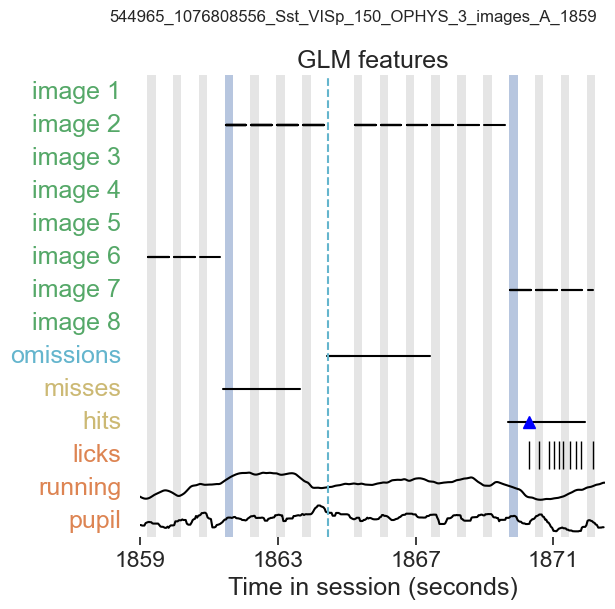

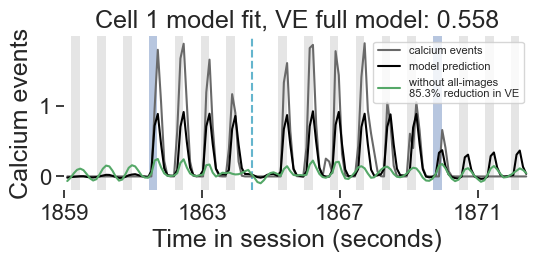

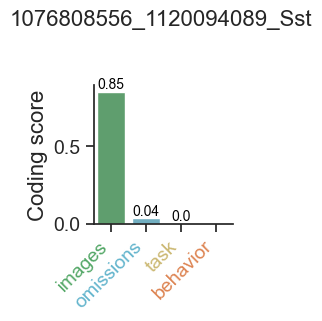

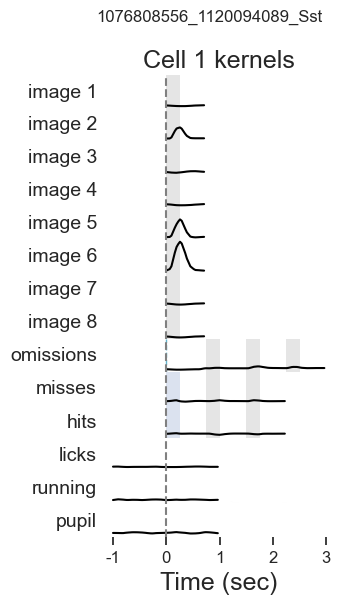

In [9]:
# 544965 - Sst - image coding
gep.plot_example_cell_all_panels(
    cell_specimen_id=1120094089,
    ophys_experiment_id=1076808556,
    start_time=1859,
    results_pivoted=results_pivoted,
    weights_df=weights_df,
    kernels=kernels,
    cell_label='Cell 1',
    save_dir=save_dir,
    folder='example_cells',
);

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

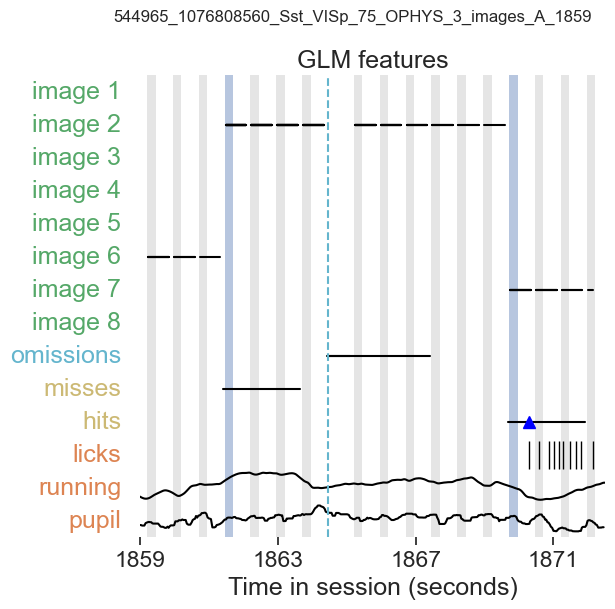

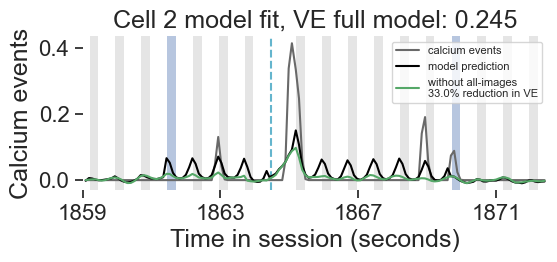

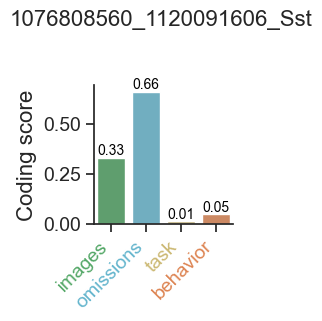

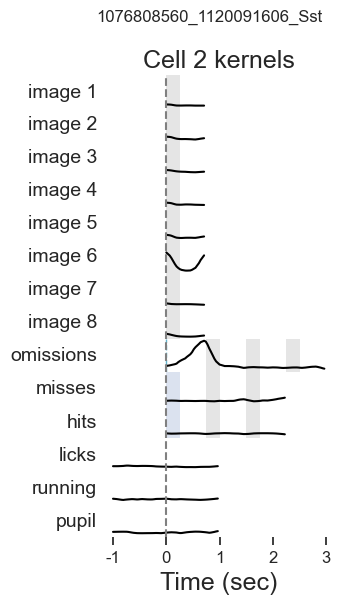

In [10]:
# 544965 - Sst - omission coding
gep.plot_example_cell_all_panels(
    cell_specimen_id=1120091606,
    ophys_experiment_id=1076808560,
    start_time=1859,
    results_pivoted=results_pivoted,
    weights_df=weights_df,
    kernels=kernels,
    cell_label='Cell 2',
    save_dir=save_dir,
    folder='example_cells',
);

#### Additional Vip examples

In [11]:
vips = results_pivoted[(results_pivoted.cell_type=='Vip Inhibitory') & 
                                    (results_pivoted.variance_explained_full>0.1) & 
                                    (results_pivoted['omissions']>0.5)].identifier.values

len(vips)

4

In [12]:
# Get saved example cells and event times of interest
example_cells_dict, example_times_dict = gep.get_glm_example_cells_and_times()
# Use custom selection
example_cells_dict = {974994093: [1086537043],
                        974994095: [1086519261],
                        974994101: [1086518655],
                        974994105: [1086524231],
                        # 905955213: [1086532875],
                        # 905955219: [1086509036],
                        1076808560: [1120091440, 1120091606],
                        1076808556: [1120094089, 1120094237, 1120094842]}


vip_example_cells_dict = {1053997501: [1086612555],
                        # 795953296: [1086490680],
                        851085100: [1086501664],
                        851085100: [1086501719]}

In [13]:
# folder = 'example_cells'

# for i, ophys_experiment_id in enumerate(list(vip_example_cells_dict.keys())):

#     ### Get data
#     dataset = loading.get_ophys_dataset(ophys_experiment_id)
#     cell_results_df, expt_results, dropouts = gep.load_glm_model_fit_results(ophys_experiment_id)

#     for cell_specimen_id in vip_example_cells_dict[ophys_experiment_id]:

        

#         ### Plot kernels and coding scores 
#         gep.plot_stacked_kernels_for_cell(cell_specimen_id, dataset, weights_df, kernels, 
#                                         save_dir=save_dir, folder=folder);

#         gep.plot_coding_score_components_for_cell(cell_specimen_id, ophys_experiment_id, results_pivoted, dataset,
#                                                     fontsize=14, as_panel=False, save_dir=save_dir, folder=folder);
    
#     ### Get time window
#     flashes_between_changes = 12
#     four_flash_dur = 6*0.75
#     start_times = utils.get_consecutive_trials_with_omission_in_middle(dataset, flashes_between_changes=flashes_between_changes)
#     for start_time in start_times[:5]:
#         xlim_seconds = [start_time, start_time+(flashes_between_changes*0.75)+four_flash_dur]
#         duration_seconds = (flashes_between_changes*0.75)+four_flash_dur
#         suffix = '_' + str(int(xlim_seconds[0]))

#         ### Plot GLM features 
#         gep.plot_glm_features_for_window(dataset, xlim_seconds, save_dir=save_dir, folder=folder, ax=None, suffix=suffix);

#         #### Plot model fit
#         gep.plot_model_fits_example_cell(cell_specimen_id, dataset, cell_results_df, dropouts, expt_results, 
#                                         'all-images', twinx=False, include_events=True, include_dff=False, 
#                                         times=xlim_seconds, save_dir=save_dir, folder=folder);     



#### Additional Sst & Excitatory examples

In [14]:
# folder = 'example_cells'

# for i, ophys_experiment_id in enumerate(list(example_cells_dict.keys())):
#     print(ophys_experiment_id)

#     ### Get data
#     dataset = loading.get_ophys_dataset(ophys_experiment_id)
#     cell_results_df, expt_results, dropouts = gep.load_glm_model_fit_results(ophys_experiment_id)

        
#     for cell_specimen_id in example_cells_dict[ophys_experiment_id]:

#         ### Get time window
#         start_time = example_times_dict[ophys_experiment_id][0]
#         flashes_between_changes = 12
#         four_flash_dur = 6*0.75
#         xlim_seconds = [start_time, start_time+(flashes_between_changes*0.75)+four_flash_dur]
#         duration_seconds = (flashes_between_changes*0.75)+four_flash_dur
#         suffix = '_' + str(int(xlim_seconds[0]))

#         ### Plot GLM features 
#         gep.plot_glm_features_for_window(dataset, xlim_seconds, save_dir=save_dir, folder=folder, ax=None, suffix=suffix);

#         #### Plot model fit
#         gep.plot_model_fits_example_cell(cell_specimen_id, dataset, cell_results_df, dropouts, expt_results, 
#                                         'all-images', twinx=False, include_events=True, include_dff=False, 
#                                     times=xlim_seconds, save_dir=save_dir, folder=folder);

#         ### Plot kernels and coding scores 
#         gep.plot_stacked_kernels_for_cell(cell_specimen_id, dataset, weights_df, kernels, 
#                                         save_dir=save_dir, folder=folder);

#         gep.plot_coding_score_components_for_cell(cell_specimen_id, ophys_experiment_id, results_pivoted, dataset,
#                                                     fontsize=14, as_panel=False, save_dir=save_dir, folder=folder);





### Image kernels for all cells 

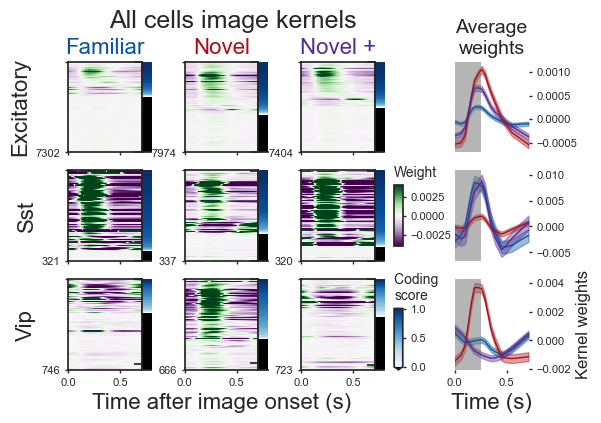

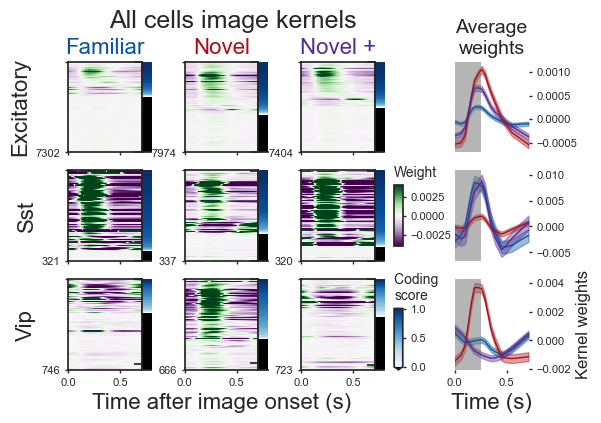

In [15]:
gep.plot_weights_and_coding_score_heatmaps_for_experience_levels_main_figure(
    'all-images', weights_df, run_params,
    row_condition='cre_line', col_condition='experience_level',
    vmax=0.004, xlabel='Time after image onset (s)', suptitle='All cells image kernels',
    save_dir=save_dir, folder='kernel_weights')


### Fraction cells coding for features

In [16]:
# Compute fraction of cells coding above threshold for each feature, per cre line
fractions = ppf.compute_feature_coding_fractions(results_pivoted, run_params, coding_thresh=0.1)

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:8738: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax[i] = sns.barplot(data=ct_data, x='feature', y='percent', order=features,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:8755: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(features, rotation=45, ha='right', fontsize=14)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:8738: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the s

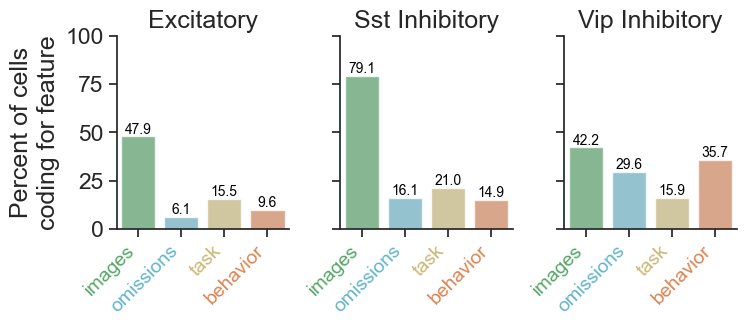

In [17]:
ppf.plot_percent_cells_coding_for_features(fractions, save_dir=save_dir, folder='coding_scores_and_kernels');

#### Maximally contributing feature 

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:8778: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  results_avg = results_pivoted.groupby(['cre_line', 'cell_specimen_id']).mean().reset_index()
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:8815: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([utils.get_abbreviated_cell_type(cre_line) for cre_line in utils.get_cre_lines()])


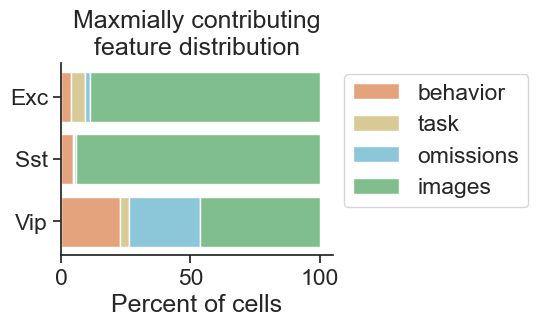

In [18]:
# Maximally contributing feature distribution
feature_counts = ppf.compute_maximally_contributing_feature(results_pivoted, matched_cells_table)
ppf.plot_maximally_contributing_feature_distribution(feature_counts, save_dir=save_dir, folder='coding_scores_and_kernels');

### Coding score distributions across experience levels

In [19]:
# Reshape coding scores for the four main features into long form for plotting
results_melted = ppf.convert_coding_scores_to_long_form_df(results_pivoted)
len(results_melted.ophys_experiment_id.unique())

402

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:8940: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(exp_level_abbreviations)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:8940: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(exp_level_abbreviations)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:8940: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(exp_level_abbreviations)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_

saving_stats


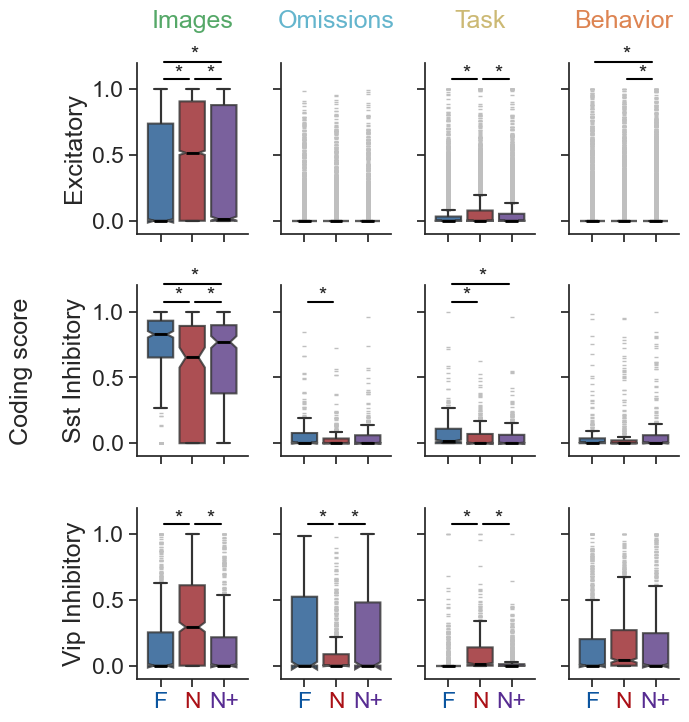

In [20]:
# Boxplots of coding score distributions by experience level, per cre line / feature
ppf.plot_coding_score_distributions_by_experience(
    results_melted, cre_lines=cre_lines,
    save_dir=save_dir, folder='coding_scores_and_kernels',
);

### Composite layout helpers (panel_grid)

Gutter-aware panel placement. Run this cell once before the composite cell.


In [21]:
from visual_behavior.visualization.panel_grid import (
    fig_setup, panel, show_label_gutters, show_decoration_zones,
    check_label_overlap, auto_fit_left,
)


## Composite figure 


In [23]:
# ---- Preload example-cell data ONCE ----
# Run this cell a single time. After that you can edit + re-run the composite
# figure cell below as many times as you like without paying the (slow)
# loading.get_ophys_dataset / load_glm_model_fit_results cost each time.
# Re-running THIS cell is also cheap: it keeps anything already cached.
CELL1 = dict(cell_id=1120094089, expt_id=1076808556, label='Cell 1')
CELL2 = dict(cell_id=1120091606, expt_id=1076808560, label='Cell 2')

example_datasets = globals().get('example_datasets', {})
example_glm_fits = globals().get('example_glm_fits', {})   # expt_id -> (cell_results_df, expt_results, dropouts)
for _cell in (CELL1, CELL2):
    _eid = _cell['expt_id']
    if _eid not in example_datasets:
        print('loading dataset + GLM fits for experiment', _eid, '...')
        example_datasets[_eid] = loading.get_ophys_dataset(_eid)
        example_glm_fits[_eid] = gep.load_glm_model_fit_results(_eid)
print('cached experiments:', list(example_datasets))


loading dataset + GLM fits for experiment 1076808556 ...


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

loading dataset + GLM fits for experiment 1076808560 ...


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

cached experiments: [1076808556, 1076808560]


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2272: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(feature_labels, rotation=45, horizontalalignment='right', fontsize=fontsize)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2272: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(feature_labels, rotation=45, horizontalalignment='right', fontsize=fontsize)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:8942: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  
/Users/marinag/Documents/Code/visual_behavior_analysis/vis

OVERLAP: axes of panel "A" intrudes into panel "A" (left gutter)
OVERLAP: axes of panel "F" intrudes into panel "F" (top gutter)
OVERLAP: axes of panel "F" intrudes into panel "F" (top gutter)
OVERLAP: axes of panel "F" intrudes into panel "F" (top gutter)
OVERLAP: axes of panel "F" intrudes into panel "F" (top gutter)


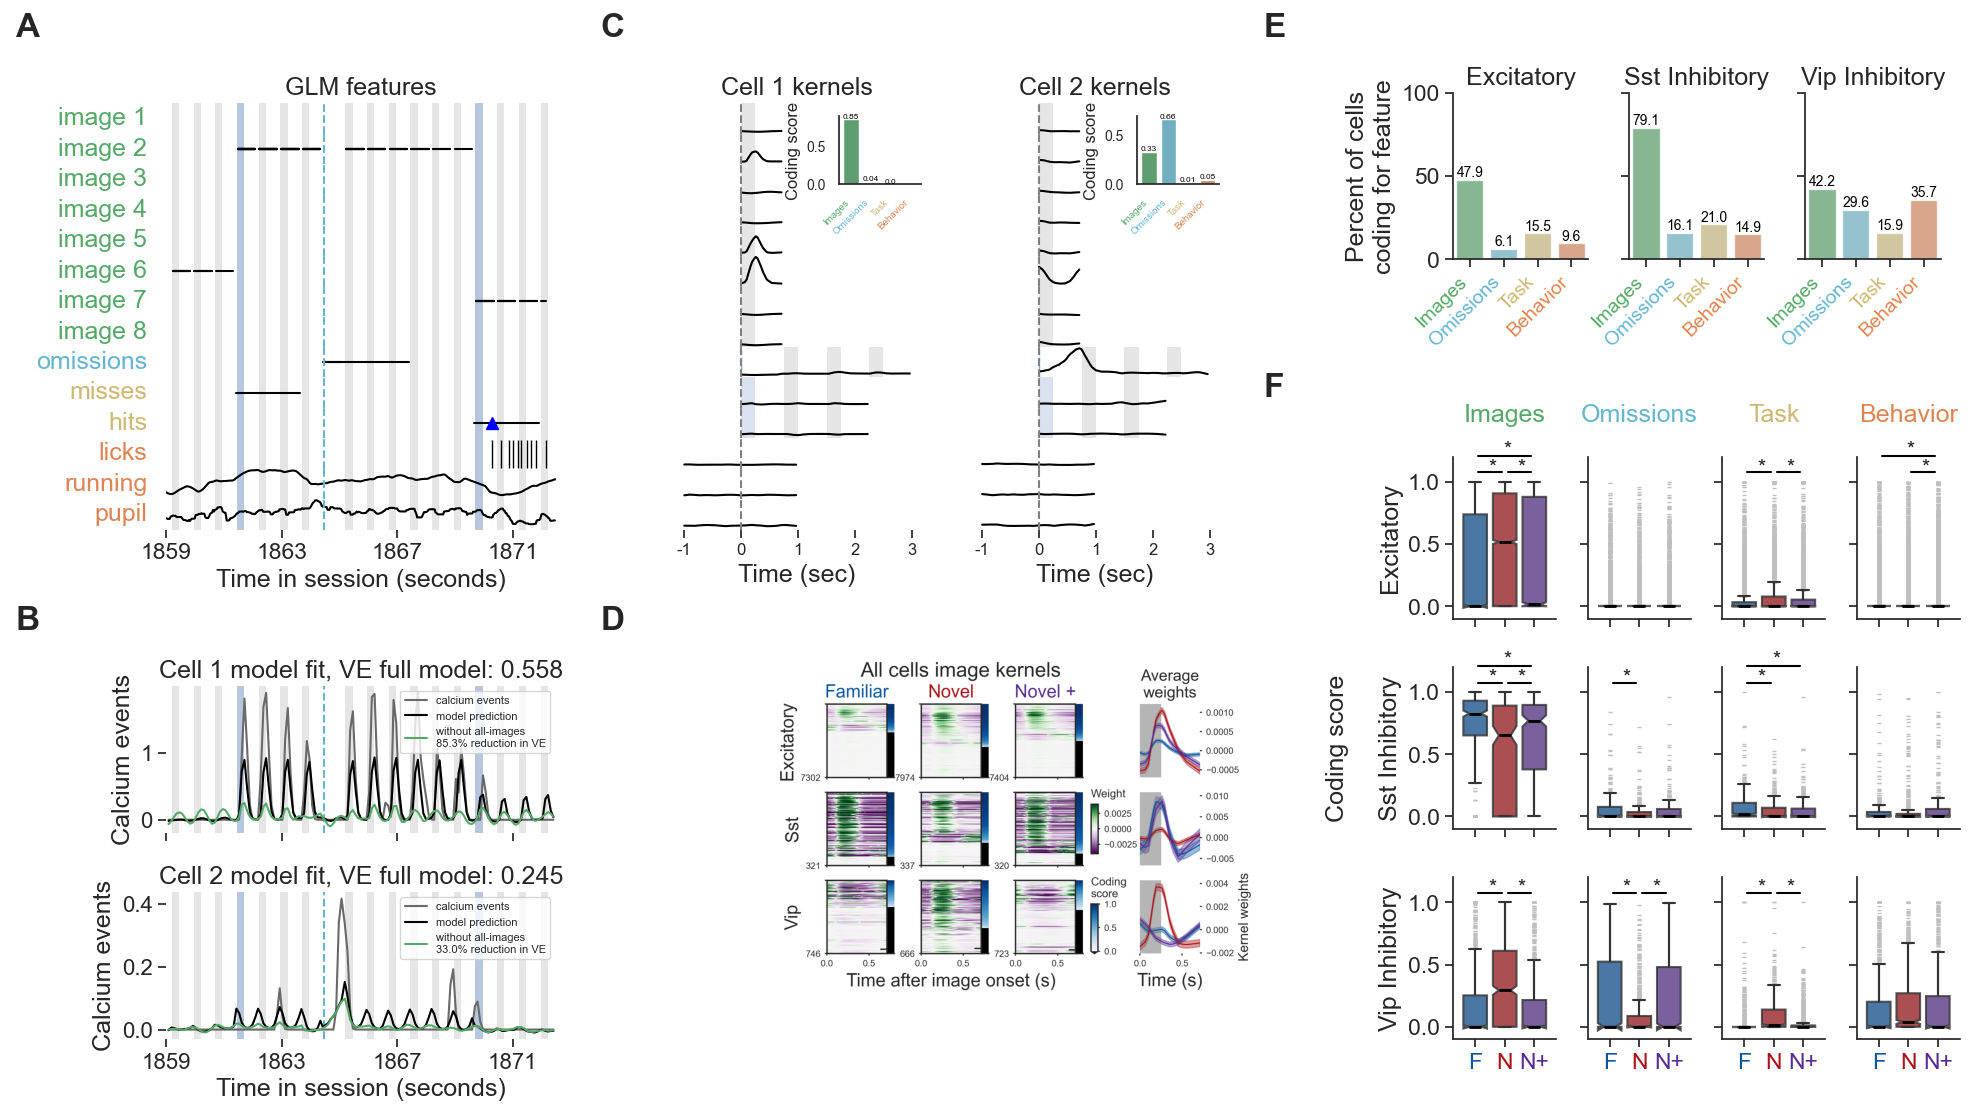

In [26]:
# Composite Figure 4 main - GLM coding analysis (cell-type-specific)
#   A GLM features for an example window
#   B Cell 1 + Cell 2 model fits (stacked)
#   C Cell 1 + Cell 2 kernels with a small coding-score-bar inset per column
#   D All-cells image kernels heatmap matrix       (loaded PNG)
#   E Percent of cells coding for each feature      (refactored: fig=, bbox=)
#   F Coding-score box-plot grid                    (refactored: fig=, bbox=)
#
# LAYOUT: figsize and REGIONS are derived directly from the panel geometry in
# 'VBO figures - revised v4.pptx' slide 8 (Figure 4), NOT eyeballed. The pptx
# figure is landscape (aspect ~1.74:1) and occupies only the top ~43% of the
# portrait slide, so the canvas is wide (19.5 x 10.4), not square. Each REGION is
# the pptx panel's letter-anchor (top-left) -> content (right/bottom), mapped to
# figure fraction, with row gaps widened to absorb x-axis labels.
import os, numpy as np
figsize = (19.5, 10.4)
fig = plt.figure(figsize=figsize)
fig_setup(fig)

REGIONS = {
    'A': [0.000, 0.285, 0.007, 0.500],   # left col, top    (shorter; x-extent matched to B)
    'B': [0.000, 0.285, 0.575, 0.998],   # left col, bottom (taller, wider; right edge title-limited)
    'C': [0.305, 0.625, 0.007, 0.500],   # mid col, top     (narrowed)
    'D': [0.305, 0.640, 0.575, 0.998],   # mid col, bottom  (narrowed)
    'E': [0.645, 0.995, 0.007, 0.240],   # right col, top   (taller; shifted left toward C/D)
    'F': [0.645, 1.000, 0.350, 0.998],   # right col, bottom (lowered; shifted left toward C/D)
}
# NOTE: gaps tuned against a faithful data-free mock until check_label_overlap is
# clean. Bottom row dropped to 0.650 so the top row's x-axis labels clear it;
# mid/right columns shifted right so B's long title and C's kernels don't enter
# the D/E gutters; F dropped to 0.450 so E's rotated x-tick labels clear it.

# CELL1, CELL2, example_datasets, example_glm_fits are defined in the
# "Preload example-cell data" cell above -- run that once, then this cell can be
# re-run repeatedly without re-loading datasets.
xlim_seconds = [1859, 1859 + 12*0.75 + 4.5]

# ---- A: GLM features (function needs an axes ARRAY of n_rows=14) ----
ax_A = panel(fig, REGIONS['A'][:2], REGIONS['A'][2:], 'A', has_title=True,
             dim=(14, 1), hspace=0.0, sharex=True,
             decoration_pt=(80, 0))   # matches B's default so A & B time axes align
gep.plot_glm_features_for_window(
    dataset=example_datasets[CELL1['expt_id']],
    xlim_seconds=xlim_seconds, title='GLM features', ax=np.asarray(ax_A),
)

# ---- B: Cell 1 + Cell 2 model fits (stacked) ----
ax_B = panel(fig, REGIONS['B'][:2], REGIONS['B'][2:], 'B', has_title=True,
             dim=(2, 1), hspace=0.4, sharex=True)
for ax, cell in zip(ax_B, [CELL1, CELL2]):
    dataset = example_datasets[cell['expt_id']]
    cell_results_df, expt_results, dropouts = example_glm_fits[cell['expt_id']]
    gep.plot_model_fits_example_cell(
        cell_specimen_id=cell['cell_id'], dataset=dataset,
        cell_results_df=cell_results_df, dropouts=dropouts, results=expt_results,
        kernel='all-images', include_events=True, include_dff=False,
        times=xlim_seconds, title=cell['label'] + ' model fit',
        twinx=False, ax=ax,
    )
# share x across the two model-fit plots: only the bottom one shows ticks + label
ax_B[0].set_xlabel(''); ax_B[0].tick_params(labelbottom=False)

# ---- C: Cell 1 + Cell 2 kernels (14 stacked rows per column) with a SMALL
#         coding-score-bar inset in the upper-right of each column.
# The pptx shows the coding-score bar as a small inset axes (~half the column
# width, upper-right), NOT a full-width row at the top -- so it is placed with
# fig.add_axes() over the top of the kernel stack, not as grid row 0.
ax_C = panel(fig, REGIONS['C'][:2], REGIONS['C'][2:], 'C', has_title=True,
             dim=(14, 2), wspace=0.2, hspace=0.0, sharex=True, sharey='col',
             decoration_pt=(14, 0))   # row labels removed -> plots sit close to the C label
# sharey='col' shares the y-axis across the 14 rows WITHIN each column (so kernel
# magnitudes are comparable down a column); the two cells keep independent scales.
# inset geometry as a fraction of each column's drawn extent -- tweak if needed
INSET_W_FRAC, INSET_H_FRAC, INSET_TOP_GAP = 0.33, 0.16, 0.03
fig.canvas.draw()   # realize gridspec positions before measuring columns
for col, cell in enumerate([CELL1, CELL2]):
    dataset = example_datasets[cell['expt_id']]
    kernel_axes = [ax_C[r][col] for r in range(14)]
    # column title 'Cell N kernels' sits on the first kernel row (top of column)
    gep.plot_stacked_kernels_for_cell(
        cell_specimen_id=cell['cell_id'], dataset=dataset,
        weights_df=weights_df, kernels=kernels, sharey=True,
        title=cell['label'] + ' kernels',
        ax=kernel_axes, scale_y=False,
    )
    # row labels are identical to panel A, so omit them in C entirely
    for a in kernel_axes:
        a.set_ylabel('')
    # small coding-score inset in the column's upper-right
    left  = min(a.get_position().x0 for a in kernel_axes)
    right = max(a.get_position().x1 for a in kernel_axes)
    top   = max(a.get_position().y1 for a in kernel_axes)
    bot   = min(a.get_position().y0 for a in kernel_axes)
    col_w, col_h = right - left, top - bot
    iw, ih = col_w * INSET_W_FRAC, col_h * INSET_H_FRAC
    ix = right - iw
    iy = top - ih - col_h * INSET_TOP_GAP
    inset_ax = fig.add_axes([ix, iy, iw, ih])
    gep.plot_coding_score_components_for_cell(
        cell_specimen_id=cell['cell_id'], ophys_experiment_id=cell['expt_id'],
        results_pivoted=results_pivoted, dataset=dataset,
        title='', horiz=False, fontsize=10, as_panel=True,
        ax=inset_ax,
    )
    # as_panel=True despines all sides; restore the left + bottom spines
    for _s in ('left', 'bottom'):
        inset_ax.spines[_s].set_visible(True)
    # as_panel=True also calls set_xlim(0, 1), which clips this 4-bar vertical
    # plot to ~2 bars; restore the full categorical x-range so all 4 show
    inset_ax.set_xlim(-0.6, 3.6)
    # add capitalized feature x-tick labels, colored to match panel E
    _feat_colors, _ = plotting.get_feature_colors_and_labels()
    inset_ax.set_xticks(range(4))
    inset_ax.set_xticklabels(['Images', 'Omissions', 'Task', 'Behavior'],
                             rotation=45, ha='right', fontsize=7)
    for _t, _c in zip(inset_ax.get_xticklabels(), _feat_colors):
        _t.set_color(_c)

# ---- D: All-cells image kernels heatmap matrix (loaded PNG) ----
# The function's internal colorbar loses GridSpec resolution when remapped into
# a narrow bbox, so it is run standalone (cell 25 saves the PNG) and loaded here.
ax_D = panel(fig, REGIONS['D'][:2], REGIONS['D'][2:], 'D')
ax_D.axis('off')
_d_png = os.path.join(save_dir, 'kernel_weight_heatmaps', 'all-images.png')
if os.path.exists(_d_png):
    ax_D.imshow(plt.imread(_d_png), aspect='equal'); ax_D.set_anchor('NW')
else:
    ax_D.text(0.5, 0.5, '[D: heatmap matrix]\nrun cell 25 first to save:\n' + _d_png,
              ha='center', va='center', fontsize=10, color='0.6', transform=ax_D.transAxes)

# ---- E: Percent of cells coding for feature (fig=, bbox=) ----
# bbox inset from the panel's top-left leaves room for the letter gutter (32x28 pt)
# plus the embedded function's own y-tick labels / subplot titles. Generous insets
# keep its decorations out of the letter gutter.
ax_E = panel(fig, REGIONS['E'][:2], REGIONS['E'][2:], 'E', has_title=True)
ax_E.axis('off')
_bbox_E = (REGIONS['E'][0] + 0.095, REGIONS['E'][2] + 0.08,
           REGIONS['E'][1],         REGIONS['E'][3])
_, ax_E_grid = ppf.plot_percent_cells_coding_for_features(fractions, fig=fig, bbox=_bbox_E)
# y is shared (sharey=True in the embedded grid); show y-tick labels on left only
for _a in np.ravel(ax_E_grid)[1:]:
    _a.tick_params(labelleft=False)
# capitalize the feature x-tick labels (preserve their per-feature colors)
for _a in np.ravel(ax_E_grid):
    _cols = [t.get_color() for t in _a.get_xticklabels()]
    _a.set_xticklabels([t.get_text().capitalize() for t in _a.get_xticklabels()],
                       rotation=45, ha='right', fontsize=14)
    for _t, _c in zip(_a.get_xticklabels(), _cols):
        _t.set_color(_c)

# ---- F: Coding-score box plot grid (fig=, bbox=) ----
ax_F = panel(fig, REGIONS['F'][:2], REGIONS['F'][2:], 'F', has_title=True)
ax_F.axis('off')
_bbox_F = (REGIONS['F'][0] + 0.095, REGIONS['F'][2] + 0.08,
           REGIONS['F'][1],         REGIONS['F'][3])
_, ax_F_grid, _ = ppf.plot_coding_score_distributions_by_experience(
    results_melted, cre_lines=cre_lines, fig=fig, bbox=_bbox_F,
)
# y is shared (sharey=True in the embedded grid); show y-tick labels on the
# leftmost column only (grid is len(cre_lines) x len(features), row-major)
_axF_flat = np.ravel(ax_F_grid)
_ncol_F = len(_axF_flat) // len(cre_lines)   # grid is len(cre_lines) x len(features)
for _i, _a in enumerate(_axF_flat):
    if _i % _ncol_F != 0:
        _a.tick_params(labelleft=False)

# ---- Audit ----
# A/B/C are multi-row axes arrays drawn by embedded functions whose long titles /
# legends extend well past their spines; D/E/F manage their own internal grid via
# bbox. auto_fit_left is therefore a no-op here (it only helps simple single-axes
# panels), so we skip it and rely on the REGIONS geometry. check_label_overlap
# still flags any decoration that bleeds into a neighbor's letter gutter.
check_label_overlap(fig, REGIONS)

utils.save_figure(fig, figsize, save_dir, 'composite', 'figure_4_main_composite')
